In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os
from numpy.fft import fft, ifft

# --- GLOBAL FONT SIZE SETTINGS ---
# Set the font size for the legend, axis labels, and tick values
# --- IEEE-style aesthetic setup ---
plt.rcParams.update(
    {
        "font.size": 12,
        "font.family": "serif",
        "axes.linewidth": 1.2,
        "axes.grid": False,
        "legend.frameon": False,
        "figure.dpi": 800,
    }
)
# ---------------------------------

fig_dir = "/home/abidhasan/Document/Project/WaveFreqAug/result_analysis/analysis"
# Ensure the directory exists (Good practice)
os.makedirs(fig_dir, exist_ok=True)

# Simulated ETTh1-like data
t = np.linspace(0, 10, 1000)
x_original = (
    np.sin(2 * np.pi * t / 5)
    + 0.5 * np.sin(2 * np.pi * t / 2)
    + 0.2 * np.random.randn(len(t))
)

# Step 1: Trend Decomposition
window = 12
trend = np.convolve(x_original, np.ones(window) / window, mode="same")
residual = x_original - trend

# Step 2: Wavelet Decomposition (simplified)
approx = trend + 0.1 * np.sin(2 * np.pi * t / 10)  # Approximation
details = residual + 0.5 * np.random.randn(len(t))  # Details

# Step 3: Adaptive Masking (simulate masking)
details_masked = details * 0.8 + 0.03 * np.random.randn(len(t))

# Step 4: Fourier Enhancement (amplify low frequencies)
f_approx = fft(approx)
amps = np.abs(f_approx)
top_k = int(len(f_approx) * 0.2)
top_indices = np.argsort(amps)[-top_k:]
f_approx[top_indices] *= 1.2
approx_enhanced = np.real(ifft(f_approx))

# Step 5: Reconstruction and Mixing
lambd = 0.7
reconstructed = approx_enhanced + details_masked
x_augmented = lambd * reconstructed + (1 - lambd) * x_original

# Simulate model outputs (for completeness - not plotted)
y_original = np.sin(2 * np.pi * (t + 2) / 5) + 0.3 * np.random.randn(len(t))
y_augmented = np.sin(2 * np.pi * (t + 2) / 5) + 0.1 * np.random.randn(len(t))

# --- Define consistent colors across plots ---
colors = {
    "original": "#1f77b4",
    "approx": "#2ca02c",
    "details": "#89897e",
    "trend": "#d62728",
    "residual": "#e8dd13",
    "masked_details": "#17becf",
    "enhanced_approx": "#e377c2",
    "reconstructed": "#ff7f0e",
}

# --- Plotting ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# The new limit is set here for all subplots:
Y_LIMITS = (-2.5, 2.5)

# (a) Original Signal
axs[0, 0].plot(
    t,
    x_original,
    label="Original Signal",
    color=colors["original"],
    alpha=0.8,
    linewidth=2,
)
axs[0, 0].set_title("(a) Step 1: Original Signal")
axs[0, 0].set_xlabel("Time")
axs[0, 0].set_ylabel("Value")
axs[0, 0].set_ylim(Y_LIMITS) # <-- Y-axis limit set
axs[0, 0].legend(loc="upper right")


# (b) Trend Decomposition
axs[0, 1].plot(t, trend, label="Trend", color=colors["trend"], alpha=0.8, linewidth=2)
axs[0, 1].plot(
    t, residual, label="Residual", color=colors["residual"], alpha=0.8, linewidth=2
)
axs[0, 1].set_title("(b) Step 1: Trend Decomposition")
axs[0, 1].set_xlabel("Time")
axs[0, 1].set_ylabel("Value")
axs[0, 1].set_ylim(Y_LIMITS) # <-- Y-axis limit set
axs[0, 1].legend(loc="upper right")


# (c) Wavelet Decomposition
axs[0, 2].plot(
    t, approx, label="Approximation", color=colors["approx"], alpha=0.8, linewidth=2
)
axs[0, 2].plot(
    t, details, label="Details", color=colors["details"], alpha=0.8, linewidth=2
)
axs[0, 2].set_title("(c) Step 2: Wavelet Decomposition")
axs[0, 2].set_xlabel("Time")
axs[0, 2].set_ylabel("Value")
axs[0, 2].set_ylim(Y_LIMITS) # <-- Y-axis limit set
axs[0, 2].legend(loc="upper right")


# (d) Adaptive Masking
axs[1, 0].plot(
    t,
    details,
    label="Original Details",
    color=colors["details"],
    alpha=0.8,
    linewidth=2,
)
axs[1, 0].plot(
    t,
    details_masked,
    label="Masked Details",
    color=colors["masked_details"],
    alpha=0.8,
    linewidth=2,
)
axs[1, 0].set_title("(d) Step 3: Adaptive Masking")
axs[1, 0].set_xlabel("Time")
axs[1, 0].set_ylabel("Value")
axs[1, 0].set_ylim(Y_LIMITS) # <-- Y-axis limit set
axs[1, 0].legend(loc="lower right")


# (e) Fourier Enhancement
axs[1, 1].plot(
    t, approx, label="Original Approx.", color=colors["approx"], alpha=0.8, linewidth=2
)
axs[1, 1].plot(
    t,
    approx_enhanced,
    label="Enhanced Approx.",
    color=colors["enhanced_approx"],
    alpha=0.8,
    linewidth=2,
)
axs[1, 1].set_title("(e) Step 4: Fourier Enhancement")
axs[1, 1].set_xlabel("Time")
axs[1, 1].set_ylabel("Value")
axs[1, 1].set_ylim(Y_LIMITS) # <-- Y-axis limit set
axs[1, 1].legend(loc="upper right")


# (f) Reconstruction & Mixing
axs[1, 2].plot(
    t, x_original, label="Original", color=colors["original"], alpha=0.8, linewidth=2
)
axs[1, 2].plot(
    t,
    x_augmented,
    label="Reconstructed & Mixed",
    color=colors["reconstructed"],
    alpha=0.8,
    linewidth=2,
)
axs[1, 2].set_title("(f) Step 5: Reconstruction & Mixing")
axs[1, 2].set_xlabel("Time")
axs[1, 2].set_ylabel("Value")
axs[1, 2].set_ylim(Y_LIMITS) # <-- Y-axis limit set
axs[1, 2].legend(loc="lower right")


# Layout and saving
# Update suptitle to use the desired size (16 for consistency with captions/legend)
plt.suptitle("Step-by-Step WaveFreq Augmentation Process", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Note: Renamed output files slightly to reflect the change
plt.savefig(
    f"{fig_dir}/figure2_steps.png",
    dpi=800,
    bbox_inches="tight",
)
plt.savefig(
    f"{fig_dir}/figure2_steps.eps",
    format="eps",
    dpi=800,
    bbox_inches="tight",
)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


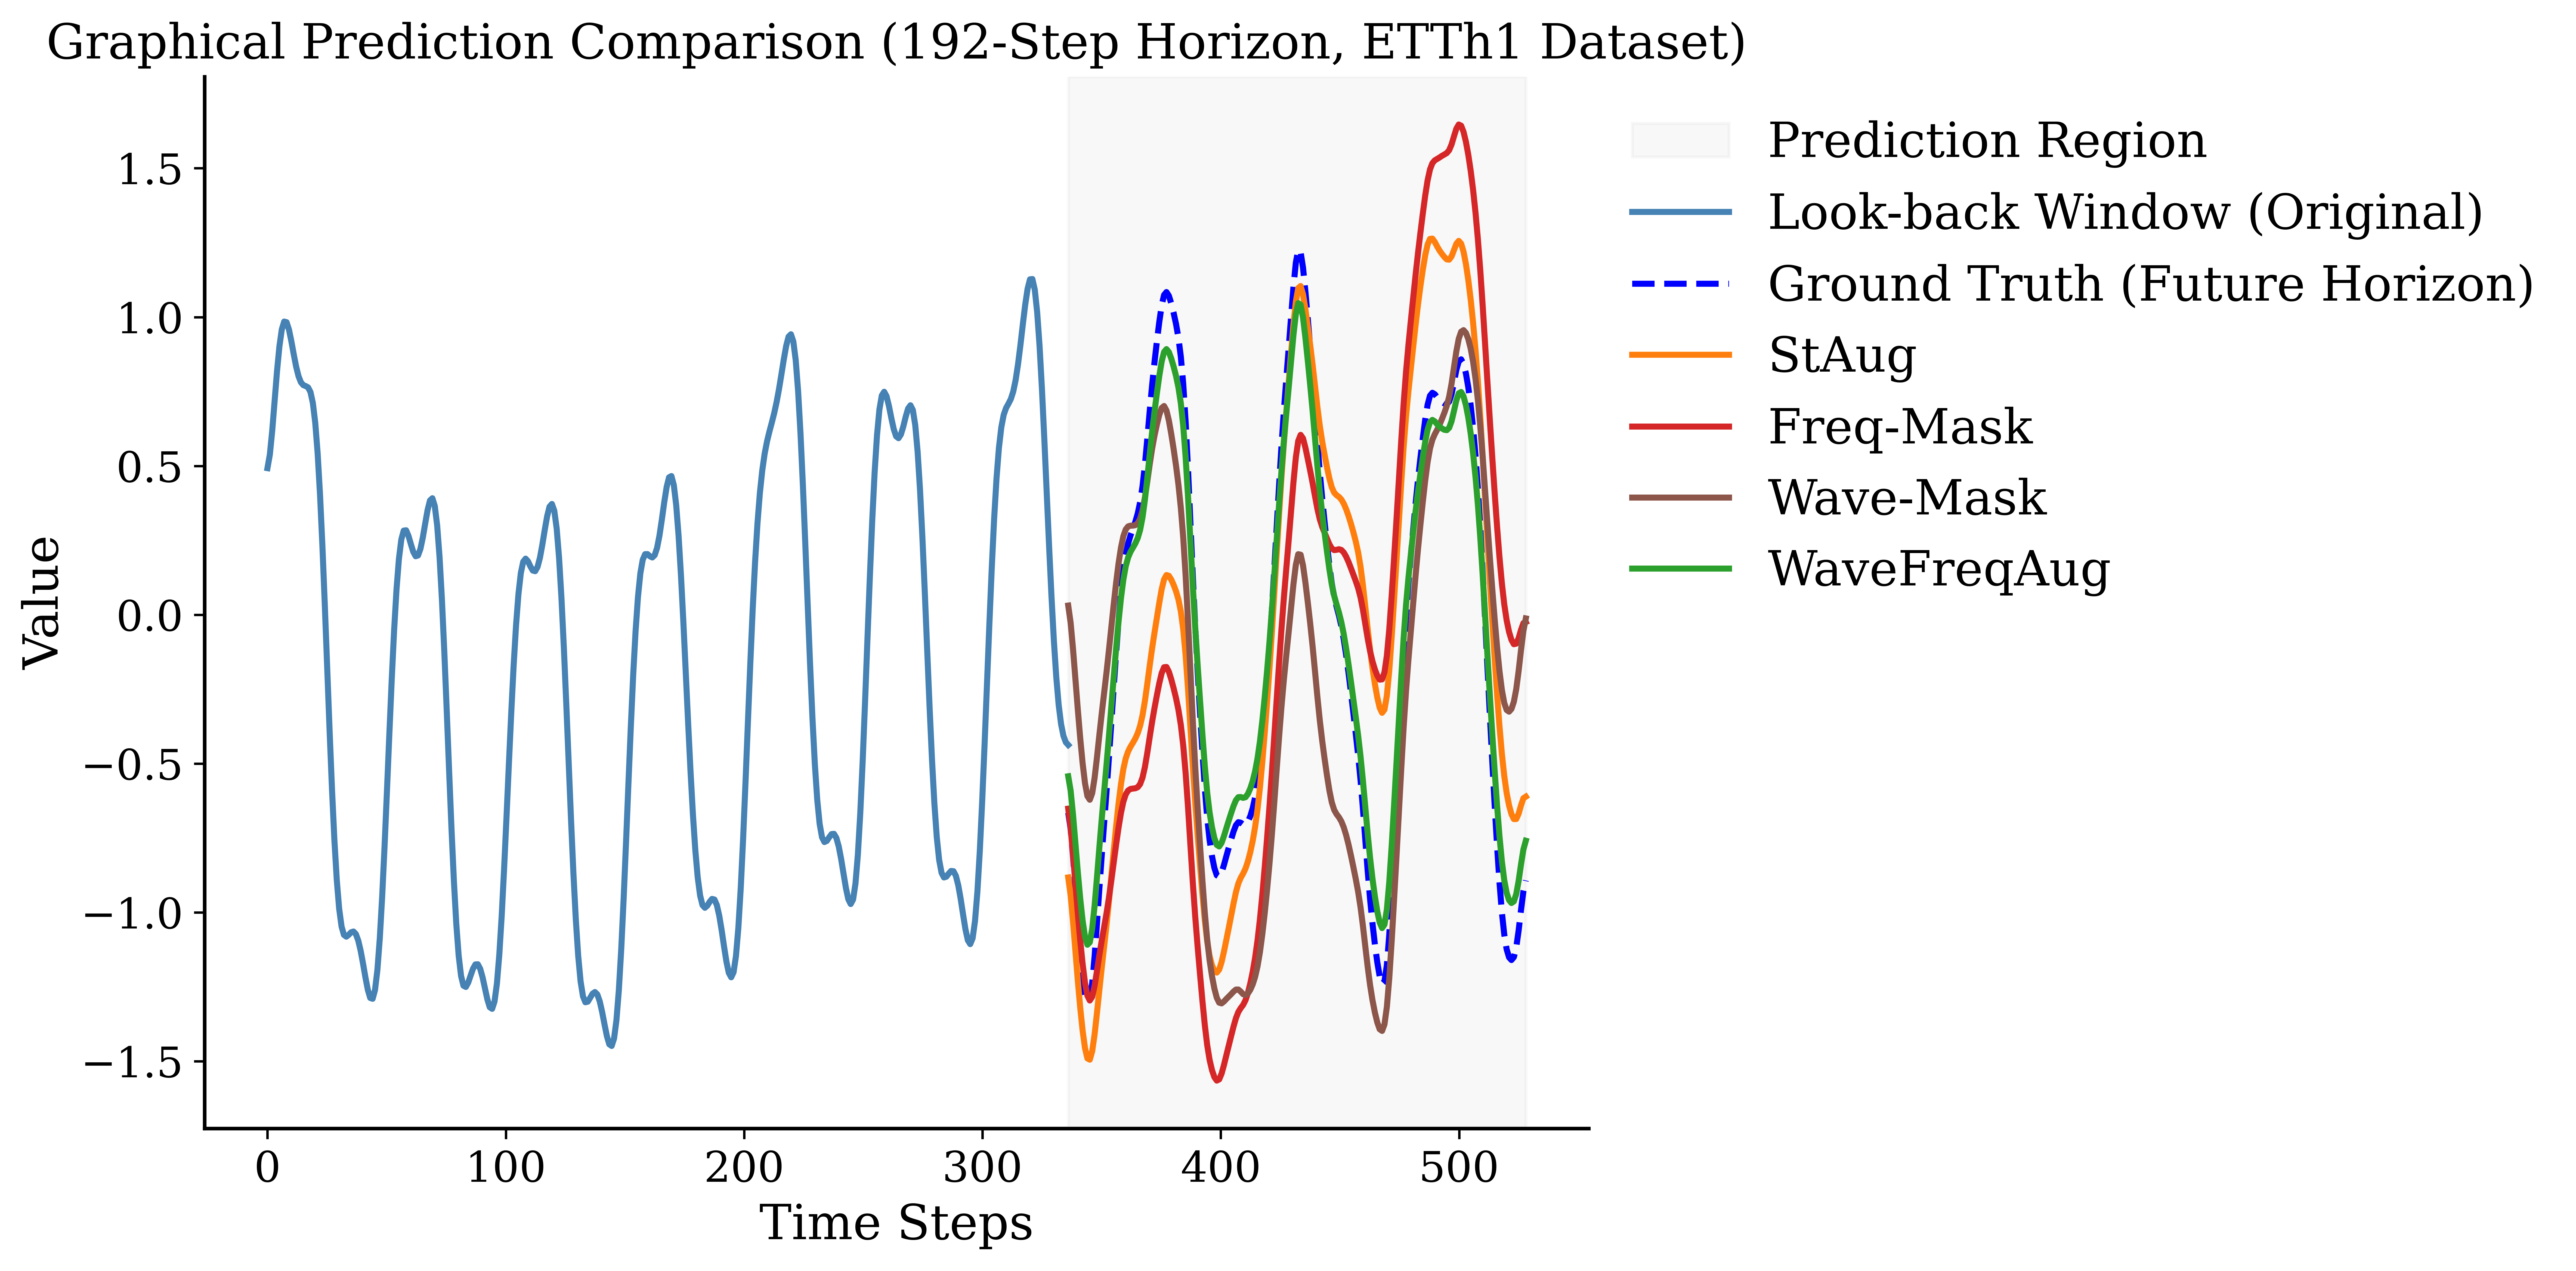

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.ndimage import gaussian_filter1d


# --- Generate Time Steps ---
t_lookback = np.linspace(0, 336, 336)
t_horizon = np.linspace(336, 336 + 192, 192)

# --- Generate Randomized Look-back Window ---
np.random.seed(42)

# Random smooth trend + local irregularities
base = np.cumsum(np.random.randn(len(t_lookback))) / 20
periodic = np.sin(2 * np.pi * t_lookback / np.random.uniform(40, 70)) + 0.4 * np.sin(
    2 * np.pi * t_lookback / np.random.uniform(15, 30)
)
x_lookback = base + periodic
x_lookback = gaussian_filter1d(x_lookback, sigma=3)

# --- Ground Truth (future horizon) ---
x_truth = (
    np.sin(2 * np.pi * t_horizon / 60)
    + 0.3 * np.sin(2 * np.pi * t_horizon / 25)
    + 0.1 * np.random.randn(len(t_horizon))
)
x_truth = gaussian_filter1d(x_truth, sigma=2)

# --- Simulated Predictions (More Realistic) ---
methods = ["StAug", "Freq-Mask", "Wave-Mask", "WaveFreqAug"]
colors = {
    "WaveFreqAug": "#2ca02c",
    "Freq-Mask": "#d62728",  # Red
    "Wave-Mask": "#8c564b",  # Brownish
    "StAug": "#ff7f0e",  # Orange
}

predictions = {}
for method in methods:
    # Accuracy & amplitude shrink levels
    if method == "WaveFreqAug":
        amp_factor, noise_level, bias_drift = 0.85, 0.05, 0.02
    elif method == "Wave-Mask":
        amp_factor, noise_level, bias_drift = 0.80, 0.07, 0.8
    elif method == "Freq-Mask":
        amp_factor, noise_level, bias_drift = 0.73, 0.08, 1
    else:  # StAug
        amp_factor, noise_level, bias_drift = 0.78, 0.1, 0.7

    # Slightly reduced amplitude
    prediction = amp_factor * x_truth

    # Add smooth random noise
    noise = noise_level * np.random.randn(len(t_horizon))
    noise = gaussian_filter1d(noise, sigma=4)

    # Add slow bias drift to simulate long-term prediction error
    drift = bias_drift * np.sin(2 * np.pi * t_horizon / np.random.uniform(150, 250))

    # Combine
    predictions[method] = prediction + noise + drift

# --- Plotting ---
plt.style.use("seaborn-v0_8-colorblind")
fig, ax = plt.subplots(figsize=(12, 6))

# Mark prediction region (optional shaded background)
ax.axvspan(336, 336 + 192, color="gray", alpha=0.05, label="Prediction Region")

# Look-back window
ax.plot(
    t_lookback,
    x_lookback,
    label="Look-back Window (Original)",
    color="steelblue",
    linewidth=2,
)

# Ground truth
ax.plot(
    t_horizon,
    x_truth,
    label="Ground Truth (Future Horizon)",
    color="Blue",
    linestyle="--",
    linewidth=2,
)

# Predictions
for method in methods:
    lw = 2 if method == "WaveFreqAug" else 2
    ax.plot(
        t_horizon, predictions[method], label=method, color=colors[method], linewidth=lw
    )

# --- Styling ---
ax.set_title(
    "Graphical Prediction Comparison (192-Step Horizon, ETTh1 Dataset)",
    fontsize=16,  # Title/Caption font size: 16 (Already correct)
)
ax.set_xlabel("Time Steps", fontsize=16)  # X-axis label font size: 16 (Already correct)
ax.set_ylabel("Value", fontsize=16)  # Y-axis label font size: 16 (Already correct)
ax.legend(
    loc="upper left", bbox_to_anchor=(1, 1), fontsize=16, frameon=False
)  # Legend font size: 16 (Adjusted from 12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(
    f"{fig_dir}/prediction_comparison_etth1_realistic.png",
    dpi=800,
    bbox_inches="tight",
)
plt.savefig(
    f"{fig_dir}/prediction_comparison_etth1_realistic.eps",
    format="eps",
    dpi=800,
    bbox_inches="tight",
)
plt.show()